<a href="https://colab.research.google.com/github/danai-coder/-danai-coder/blob/main/ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns


In [5]:
diamonds = sns.load_dataset('diamonds', cache=False)

In [6]:
diamonds.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [88]:
diamonds['color'].value_counts()

,count
color,
G,11292
E,9797
F,9542
H,8304
D,6775
I,5422
J,2808


In [17]:
colorless = diamonds[diamonds['color'].isin(['E','F','H','D','I'])]
colorless['color'].values.unique()
colorless = colorless[['color', 'price']].reset_index(drop=True)
colorless.head()

,color,price
0,E,326
1,E,326
2,E,327
3,I,334
4,I,336


In [21]:
colorless.isna().sum()

,0
color,0
price,0


In [28]:
import math
colorless.insert(2, 'log_price', [math.log(price) for price in colorless['price']])
colorless.head()

,color,price,log_price
0,E,326,5.786897
1,E,326,5.786897
2,E,327,5.789960
3,I,334,5.811141
4,I,336,5.817111


In [30]:
colorless.to_csv('diamonds.csv', index=False, header=list(colorless.columns))

In [32]:
df = pd.read_csv('diamonds.csv')

In [33]:
df.head()

,color,price,log_price
0,E,326,5.786897
1,E,326,5.786897
2,E,327,5.789960
3,I,334,5.811141
4,I,336,5.817111


<Axes: xlabel='color', ylabel='log_price'>

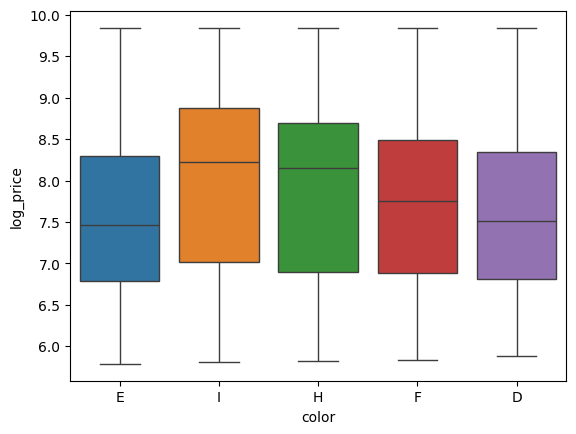

In [36]:
sns.boxplot(x='color', y='log_price', hue='color', data=df)

In [40]:
model = ols(formula='log_price ~ C(color)', data=df).fit()

In [41]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     265.0
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          3.61e-225
Time:                        17:03:27   Log-Likelihood:                -56182.
No. Observations:               39840   AIC:                         1.124e+05
Df Residuals:                   39835   BIC:                         1.124e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.6169      0.012    632.421      0.000       7.593       7.641
C(color)[T.E]    -0.0375      0.016     -2.394      0.017      -0.068      -0.007
C(color)[T.F]     0.1455      0.016      9.240      0.000       0.115       0.176
C(color)[T.H]     0.3015      0.016     18.579      0.000       0.270       0.333
C(color)[T.I]     0.4061      0.018     22.479      0.000       0.371       0.441
==============================================================================
Omnibus:                     7112.992   Durbin-Watson:                   0.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1542.881
Skew:                           0.079   Prob(JB):                         0.00
Kurtosis:                       2.049   Cond. No.                         6.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(color),1041.690290,4.0,264.987395,3.609774e-225
Residual,39148.779822,39835.0,NaN,NaN


In [44]:
sm.stats.anova_lm(model, typ=3)

,sum_sq,df,F,PR(>F)
Intercept,393066.804852,1.0,399956.684283,0.000000e+00
C(color),1041.690290,4.0,264.987395,3.609774e-225
Residual,39148.779822,39835.0,NaN,NaN


In [45]:
sm.stats.anova_lm(model, typ=1)

,df,sum_sq,mean_sq,F,PR(>F)
C(color),4.0,1041.690290,260.422572,264.987395,3.609774e-225
Residual,39835.0,39148.779822,0.982773,NaN,NaN


According to the above assesment since the p value is very small typically less than 0.05 we reject the null hypothesis whic basically says there is no difference between prices and color and we can conclude theat there is a signficant difference in pricebetween the different color diamonds

In [46]:
diamond = sns.load_dataset('diamonds', cache=False)

In [47]:
diamond.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [72]:
diamond1 = diamond[['cut','color','price']]
diamond1 = diamond1[diamond1['cut'].isin(["Ideal","Premium","Very Good"])]
diamond1 = diamond1[diamond1['color'].isin(['E','F','H','D','I'])]
diamond1['log_price'] = [math.log(price) for price in diamond1['price']]
diamond1.head()

,cut,color,price,log_price
0,Ideal,E,326,5.786897
1,Premium,E,326,5.786897
3,Premium,I,334,5.811141
6,Very Good,I,336,5.817111
7,Very Good,H,337,5.820083


In [73]:
diamond1.reset_index(inplace=True, drop=True)
diamond1.head()

,cut,color,price,log_price
0,Ideal,E,326,5.786897
1,Premium,E,326,5.786897
2,Premium,I,334,5.811141
3,Very Good,I,336,5.817111
4,Very Good,H,337,5.820083


In [74]:
diamond1.to_csv('diamonds1.csv', index=False, header=list(diamond1.columns))

In [75]:
diam = pd.read_csv('diamonds1.csv')
diam.head()

,cut,color,price,log_price
0,Ideal,E,326,5.786897
1,Premium,E,326,5.786897
2,Premium,I,334,5.811141
3,Very Good,I,336,5.817111
4,Very Good,H,337,5.820083


In [76]:
model1 = ols(formula='log_price ~ C(cut) + C(color)+ C(cut):C(color)', data=diam).fit()

In [77]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     119.5
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:32:52   Log-Likelihood:                -49159.
No. Observations:               34935   AIC:                         9.835e+04
Df Residuals:                   34920   BIC:                         9.847e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             7.4567      0.019    401.583      0.000       7.420       7.493
C(cut)[T.Premium]                     0.2828      0.031      9.153      0.000       0.222       0.343
C(cut)[T.Very Good]                   0.2295      0.031      7.290      0.000       0.168       0.291
C(color)[T.E]                        -0.0056      0.024     -0.231      0.817      -0.053       0.042
C(color)[T.F]                         0.1755      0.024      7.166      0.000       0.128       0.224
C(color)[T.H]                         0.2756      0.026     10.739      0.000       0.225       0.326
C(color)[T.I]                         0.3787      0.028     13.294      0.000       0.323       0.435
C(cut)[T.Premium]:C(color)[T.E]      -0.0322      0.040     -0.800      0.424      -0.111       0.047
C(cut)[T.Very Good]:C(color)[T.E]    -0.0931      0.041     -2.294      0.022      -0.173      -0.014
C(cut)[T.Premium]:C(color)[T.F]       0.0313      0.040      0.775      0.438      -0.048       0.110
C(cut)[T.Very Good]:C(color)[T.F]    -0.1013      0.041     -2.459      0.014      -0.182      -0.021
C(cut)[T.Premium]:C(color)[T.H]       0.0947      0.041      2.308      0.021       0.014       0.175
C(cut)[T.Very Good]:C(color)[T.H]    -0.0247      0.043     -0.576      0.564      -0.109       0.059
C(cut)[T.Premium]:C(color)[T.I]       0.0841      0.046      1.832      0.067      -0.006       0.174
C(cut)[T.Very Good]:C(color)[T.I]     0.0359      0.048      0.753      0.451      -0.057       0.129
==============================================================================
Omnibus:                     4862.888   Durbin-Watson:                   0.101
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1246.556
Skew:                           0.108   Prob(JB):                    2.06e-271
Kurtosis:                       2.100   Cond. No.                         20.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [78]:
sm.stats.anova_lm(model1, typ=2)

,sum_sq,df,F,PR(>F)
C(cut),630.641441,2.0,322.706309,1.348511e-139
C(color),926.361461,4.0,237.014783,3.481145e-201
C(cut):C(color),27.478611,8.0,3.515279,4.531734e-04
Residual,34120.806577,34920.0,NaN,NaN


In [79]:
sm.stats.anova_lm(model1, typ=3)

,sum_sq,df,F,PR(>F)
Intercept,157578.043681,1.0,161268.910012,0.000000e+00
C(cut),100.144107,2.0,51.244864,5.987341e-23
C(color),319.145817,4.0,81.655250,4.134649e-69
C(cut):C(color),27.478611,8.0,3.515279,4.531734e-04
Residual,34120.806577,34920.0,NaN,NaN


In [80]:
sm.stats.anova_lm(model1, typ=1)

,df,sum_sq,mean_sq,F,PR(>F)
C(cut),2.0,681.475794,340.737897,348.718819,1.111426e-150
C(color),4.0,926.361461,231.590365,237.014783,3.481145e-201
C(cut):C(color),8.0,27.478611,3.434826,3.515279,4.531734e-04
Residual,34920.0,34120.806577,0.977114,NaN,NaN


In [81]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [84]:
turkey_pair = pairwise_tukeyhsd(endog=diam['log_price'], groups=diam['color'], alpha=0.05)

In [85]:
turkey_pair.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
D,E,-0.0345,0.2406,-0.0804,0.0113,False
D,F,0.1623,0.0,0.1161,0.2085,True
D,H,0.3142,0.0,0.2667,0.3618,True
D,I,0.4227,0.0,0.3696,0.4757,True
E,F,0.1968,0.0,0.155,0.2387,True
E,H,0.3488,0.0,0.3055,0.392,True
E,I,0.4572,0.0,0.4079,0.5064,True
F,H,0.1519,0.0,0.1083,0.1956,True
F,I,0.2603,0.0,0.2108,0.3099,True
H,I,0.1084,0.0,0.0576,0.1593,True


In [86]:
turkey_pair_cut = pairwise_tukeyhsd(endog=diam['log_price'], groups=diam['cut'], alpha=0.05)

In [87]:
turkey_pair_cut.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Ideal,Premium,0.3286,0.0,0.2986,0.3585,True
Ideal,Very Good,0.1803,0.0,0.1494,0.2112,True
Premium,Very Good,-0.1483,0.0,-0.1823,-0.1143,True
